Importujemy biblioteki

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Pobieramy dane

In [170]:
titanic_data = pd.read_csv('titanic.csv');
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [171]:
titanic_data.shape

(891, 12)

In [172]:
missing_rows = titanic_data.isna().sum(axis=0)
missing_rows

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98


Jak widać w 77% przypadków nie ma podanej kabiny, więc nie będziemy brać jej pod uwagę. Teraz musimy sprawdzić rozkłady wieku, cen biletu oraz skąd osoby wypływały.

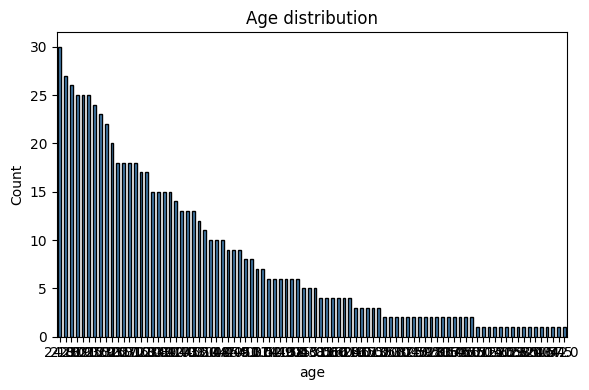

In [173]:
counts = titanic_data['Age'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Age distribution')
plt.xlabel('age')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Dla wieku postanowiłem losowo wybrać wartości. Nie wiem czemu, po prostu dla mnie to miało sens xd.

In [174]:
age_count_prob = titanic_data['Age'].value_counts(normalize=True)
missing_titanic_age = titanic_data.Age.isna()
titanic_data.loc[missing_titanic_age, 'Age'] = np.random.choice(age_count_prob.index,size=missing_titanic_age.sum(), p=age_count_prob.values)

Dla cen biletów widać, że średnia jest wyższa niż mediana, aby nie zaburzać mediany postanowiłeś reszcie osób (które nie mają podanej ceny biletu) wpisać cenę mediany.

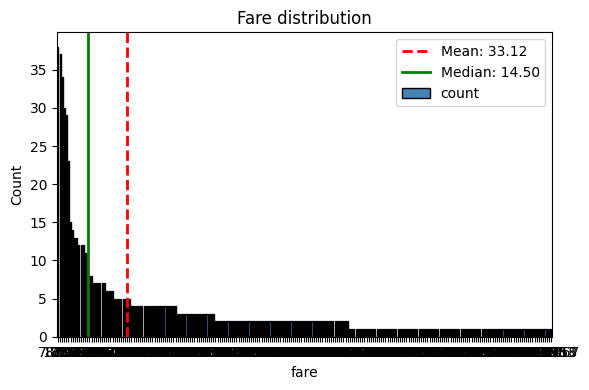

In [175]:
data = titanic_data['Fare'].dropna();
mean_val = data.mean();
median_val = data.median();

counts = titanic_data['Fare'].value_counts()
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Fare distribution')
plt.xlabel('fare')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [176]:
missing_titanic_fare = titanic_data.Fare.isna()
titanic_data.loc[missing_titanic_fare, 'Fare'] = median_val

Widać, że najczęściej osoby wypływały z "Southampton", dlatego możemy to wpisać do osób, które nie mają tej wartości podanej.

In [177]:
titanic_data.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [178]:
missing_titanic_embarked = titanic_data.Embarked.isna()
titanic_data.loc[missing_titanic_embarked, 'Embarked'] = 'S'

Usuwamy zbędnę kolumny

In [179]:
titanic_data = titanic_data.drop('PassengerId', axis=1);
titanic_data = titanic_data.drop('Name', axis=1)
titanic_data = titanic_data.drop('Cabin', axis=1)
titanic_data = titanic_data.drop('Ticket', axis=1)

Dopisujemy kolumny, które mówią czy osoba jest jak Jack lub jak Rose. Jack jest młodym chłopakiem z 3 klasy, a Rose młodą dziewczyną z 1 klasy.

In [180]:
Like_Jack_data = (titanic_data.Age < 23) & (titanic_data.Age > 18) & (titanic_data.Pclass == 3) & (titanic_data.Sex == "male")
is_like_Jack = pd.Series(data=Like_Jack_data, index=titanic_data.index, name='Like_Jack')
titanic_data = pd.concat([titanic_data, is_like_Jack], axis=1)

In [181]:
Like_Rose_data = (titanic_data.Age < 22) & (titanic_data.Age > 16) & (titanic_data.Pclass == 1) & (titanic_data.Sex == "female")
is_like_Rose = pd.Series(data=Like_Rose_data, index=titanic_data.index, name='Like_Rose')
titanic_data = pd.concat([titanic_data, is_like_Rose], axis=1)


Mapujemy wartości na 0 i 1

In [182]:
Sexmap = {'male':0, 'female':1}
titanic_data.Sex = titanic_data.Sex.map(Sexmap).astype('int8')

Booleanmap = {False:0,True:1}
titanic_data.Like_Jack = titanic_data.Like_Jack.map(Booleanmap).astype('int8')
titanic_data.Like_Rose = titanic_data.Like_Rose.map(Booleanmap).astype('int8')

Dodajemy one-hot encoding to Embarked ponieważ istnieją tylko 3 wartości.

In [183]:
titanic_data = pd.get_dummies(data=titanic_data, prefix='Embarked', columns=['Embarked'], dtype=np.int32)

Do wieku wykorzystujemy minMax, poenieważ nie istiał jakiś szczególny outliner. Wszystkie dane miały biologiczny sens.

Dla cen biletów, wykorzystujemy logarytm. Na poprzenim wykresie było widać bardzo długi prawostronny ogon.

In [184]:
titanic_data.Age = (titanic_data.Age - titanic_data.Age.min()) / (titanic_data.Age.max() - titanic_data.Age.min())
titanic_data.Fare = np.log1p(titanic_data.Fare)

In [185]:
def plot_correlation_matrix(df):
    """
    Plots a heatmap showing the correlation matrix for numeric columns in the DataFrame.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing numeric data.
    Returns:
        None. Displays the correlation heatmap.
    """
    # compute correlation matrix only for numeric columns
    corr = df.corr(numeric_only=True)

    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

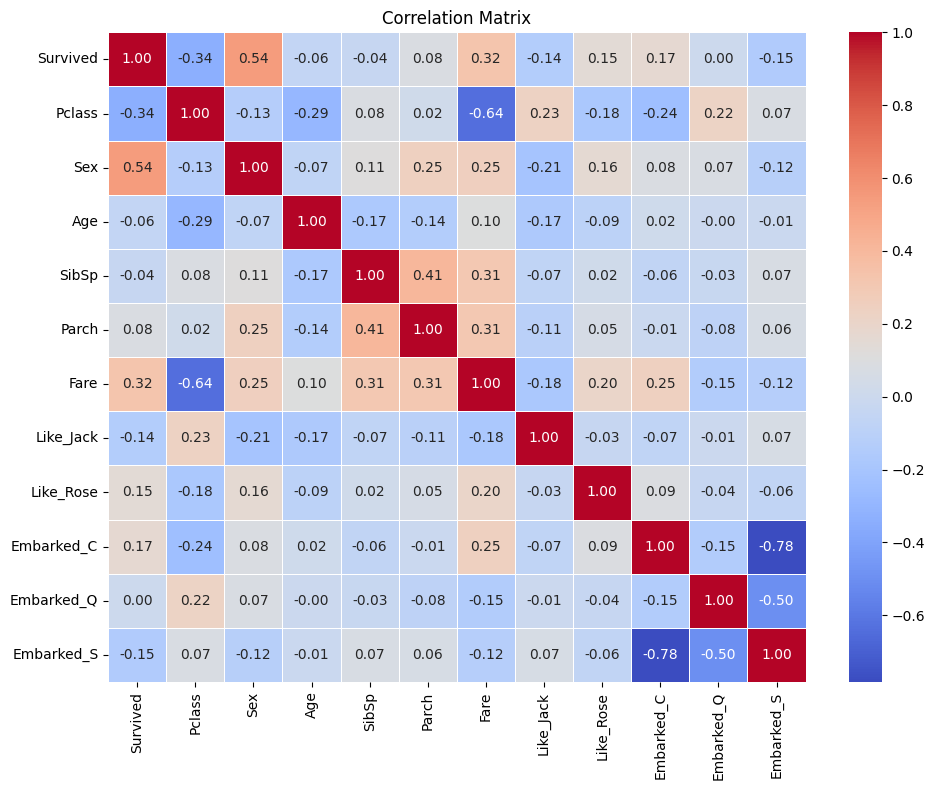

In [186]:
plot_correlation_matrix(titanic_data)

Największy wpływ na przetrwanie miała płec oraz cena biletu. Zdziwił mnie brak zależności wieku a przetwania. Faktycznie widać, że Rose miała większą szansę na przeżycie niż Jack. Pclass miało wpływ na brak przeżycia, nie do końca rozumiem czemu, skoro 1 klasa to ta najlepsza to z nią też powinno iść przeżycie, widać jednak, że Fare oraz Pclass mają ze sobą silną negatywną korelacje. Nie wiem jak to odczytać czy to nam mówi 'Im wyższy fare tym niższy Pclass'? Jeżeli tak to ma to sens, ale z Pclass nie idzie przetrwanie. Dobra czaję im wyższy Pclass tym mniej przeżywało, ma sens.